# CAR PRICE PREDICTOR + DATA ANALYSER

**Dataset :** https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data 

**Business Problem :**
Used car prices are highly variable and opaque to buyers. The goal is to build a regression model that predicts the fair market price of a used car based on its features , helping buyers avoid overpaying and sellers price competitively.

**Approaches :**

1. Importing Libraries
2. Importing CSV file
3. Data Preprocessing -
   - Basic Data insights
   - Finding Duplicates
   - Outliers
4. EDA
   - Outliers Handling
   - Data Visualization
5. Feature Engineering
   - Reducing Cardinality
   - Creating New Features
6. Train Test Split
7. Model Pipeline
   - Model Preprocessing
   - Model Selection
   - Linear Regression
     
           i) Creating Pipeline
           ii) Evaluation
    - Random Forest
      
           i) Creating Pipeline
           ii) Evaluation
    - Feature Importance
    - XGBoost
      
           i) Default XGBoost
           ii) Tune XGBoost
           iii) Log Transform in XGBoost
8. Saving Model in Pickle File
9. Conclusion

# 1. Importing Libraries

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder,OrdinalEncoder)
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression,SelectKBest
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import joblib

# 2. Importing CSV file

In [2]:
car_price=pd.read_csv("vehicles.csv")

# 3. Data Preprocessing

## 3.1 Basic Data Insights

In [3]:
car_price.shape

(426880, 26)

In [4]:
car_price.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [5]:
car_price.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [6]:
car_price.dtypes

id                int64
url              object
region           object
region_url       object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
image_url        object
description      object
county          float64
state            object
lat             float64
long            float64
posting_date     object
dtype: object

In [7]:
car_price.tail()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


In [8]:
car_price.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [9]:
car_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

#### Columns like ['url','region_url','lat','long','posting_date','image_url','description','county','description','VIN','id'] does not affects the price of car therefore removing them.

In [10]:
car_price=car_price.drop(columns=
                         ['url','region_url','lat','long','posting_date','image_url','description','county','description','VIN','id','size'])

In [11]:
car_price=car_price.drop(columns='region')

#### columns left after dropping noise columns are :

In [12]:
car_price.columns

Index(['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type',
       'paint_color', 'state'],
      dtype='object')

#### Finding percentage of total Null values for each column

In [13]:
def null_percentage():
    for col in car_price.columns:
        print(f"{col} null value percentage:")
        print(f"{( car_price[col].isnull().sum() ) / (car_price.shape[0]) *100} % \n")

null_percentage()

price null value percentage:
0.0 % 

year null value percentage:
0.28228073463268366 % 

manufacturer null value percentage:
4.133714392803598 % 

model null value percentage:
1.2361787856071964 % 

condition null value percentage:
40.78523238380809 % 

cylinders null value percentage:
41.6224700149925 % 

fuel null value percentage:
0.7058189655172414 % 

odometer null value percentage:
1.0307346326836582 % 

title_status null value percentage:
1.9307533733133435 % 

transmission null value percentage:
0.5987631184407797 % 

drive null value percentage:
30.586347451274364 % 

type null value percentage:
21.752717391304348 % 

paint_color null value percentage:
30.501077586206897 % 

state null value percentage:
0.0 % 



#### Since the sum of null values of columns ['transmission','fuel','year','model','odometer','title_status'] are less than 5% therefore removing them as this will not affect the result 

In [14]:
car_price=car_price.dropna(subset=['transmission','fuel','year','model','odometer','title_status'])

#### Finding the Shape of data after removing null values

In [15]:
car_price.shape

(405594, 14)

#### Only 4.95% of data is removed

## 3.2 Finding Duplicates

In [16]:
car_price.duplicated().sum()

np.int64(120590)

#### there are 52,601 duplicate rows in the DataFrame therefore removing them 

In [132]:
car_price=car_price.drop_duplicates()

# 3.3 Outliers

In [18]:
def outliers():
    columns_car=['price',	'year',	'odometer']
    for col in columns_car:
        
        print(col)
        print(f"skewness: {car_price[col].skew()}")
outliers()

price
skewness: 242.32488137387702
year
skewness: -3.2403455015242613
odometer
skewness: 36.324393961433906


# 4. EDA(Exploratory Data Analysis)

## 4.1 Outlier Handling

#### The data removed is either:
- Incomplete records (nulls)
- Garbage price entries ($500 cars, billion dollar entries)

#### For Price

In [19]:
car_price['price'].sort_values(ascending=False).head(20)

356716    3736928711
318592    3736928711
91576     3024942282
257840    3024942282
184704    1410065407
153082    1234567890
29386     1111111111
230753     135008900
207080     123456789
358555     123456789
288356     123456789
307488     123456789
137807     123456789
193736     123456789
1838        99999999
379133      25003000
136516      17000000
353641      11111111
300308      10004000
105843       6995495
Name: price, dtype: int64

In [20]:
car_price['price'].sort_values(ascending=False).tail(20)

407600    0
407617    0
196425    0
365609    0
146568    0
407634    0
407633    0
124284    0
352702    0
407630    0
407629    0
407627    0
390365    0
407626    0
62064     0
222923    0
407623    0
407622    0
222935    0
373099    0
Name: price, dtype: int64

In [21]:
car_price= car_price[
    (car_price['price'] >=1000 ) & 
    (car_price['price'] <=100000)]

#### 320,679  →  after price filtering (lost ~21%) 


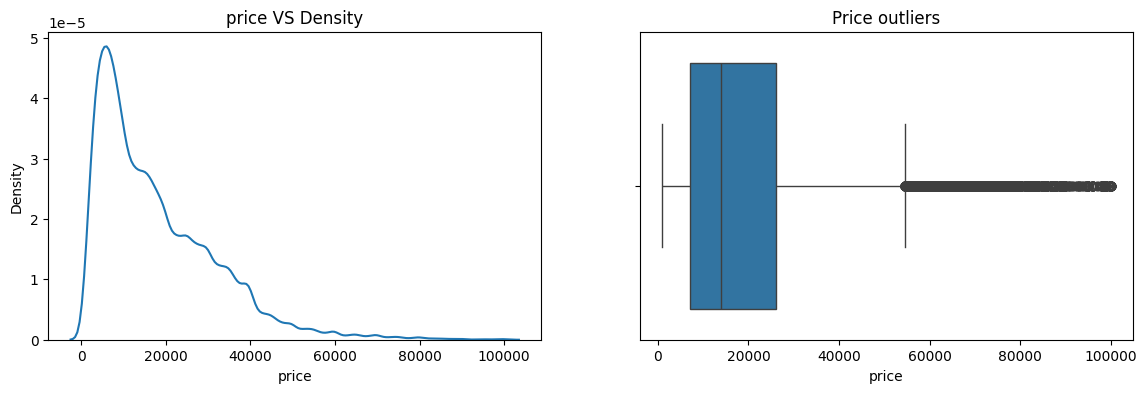

In [22]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(car_price['price'])
plt.title('price VS Density')

plt.subplot(122)
sns.boxplot(x=car_price['price'])
plt.title('Price outliers')
plt.show()

#### For Year

In [23]:
car_price['year'].value_counts().sort_values(ascending=False).head(20)

year
2018.0    20298
2017.0    18854
2013.0    17756
2015.0    17249
2014.0    16835
2016.0    16079
2012.0    14382
2019.0    13536
2011.0    12773
2008.0    11818
2007.0    10439
2010.0    10279
2020.0    10174
2006.0     9181
2009.0     8243
2005.0     7763
2004.0     6619
2003.0     5388
2002.0     4256
2001.0     3380
Name: count, dtype: int64

In [24]:
car_price['year'].value_counts().sort_values(ascending=False).tail(20)

year
1935.0    18
1933.0    18
1942.0    11
1926.0     9
1924.0     7
1925.0     5
1944.0     3
1900.0     2
1913.0     2
1921.0     2
1945.0     2
1920.0     2
1910.0     2
1918.0     1
1916.0     1
1943.0     1
1922.0     1
1915.0     1
1901.0     1
1905.0     1
Name: count, dtype: int64

In [25]:
car_price=car_price[
    car_price['year'] >=1990]

#### 320,679  →  after year filtering (lost ~3.2%) 


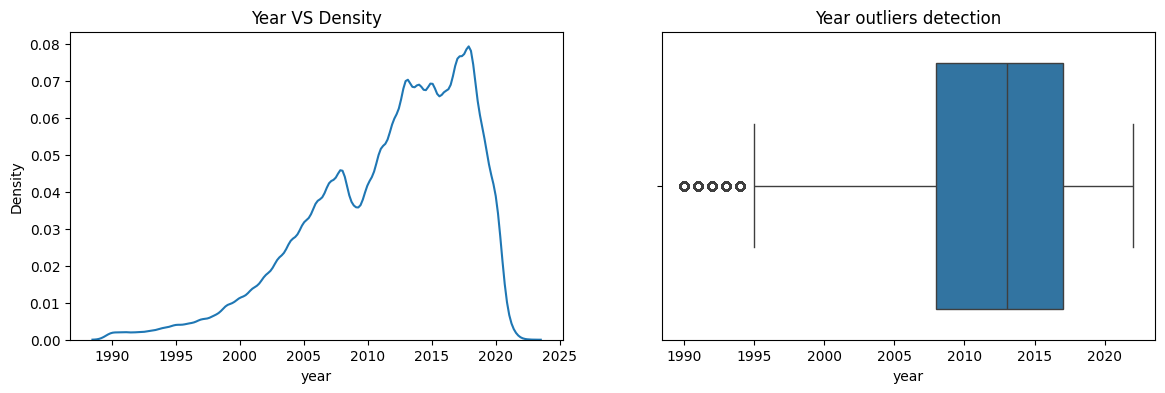

In [26]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(car_price['year'])
plt.title('Year VS Density')

plt.subplot(122)
sns.boxplot(x=car_price['year'])
plt.title('Year outliers detection')

plt.show()

#### For odometer

In [27]:
car_price['odometer'].sort_values(ascending=False).head(100)

144436    10000000.0
340694    10000000.0
305172    10000000.0
378708     9999999.0
328374     9999999.0
             ...    
332713     1755817.0
101915     1750000.0
392708     1720466.0
358667     1711374.0
176057     1701289.0
Name: odometer, Length: 100, dtype: float64

In [28]:
car_price['odometer'].sort_values(ascending=False).tail(10000)

304494    7000.0
79550     7000.0
189804    7000.0
34513     7000.0
29579     7000.0
           ...  
56077        0.0
373563       0.0
56082        0.0
222681       0.0
231995       0.0
Name: odometer, Length: 10000, dtype: float64

In [29]:
car_price=car_price[
    (car_price['odometer']>=0) &
    (car_price['odometer']<=300000)]

In [30]:
car_price.shape

(247282, 14)

#### 320,679  →  after odometer filtering (lost ~2000 rows) 

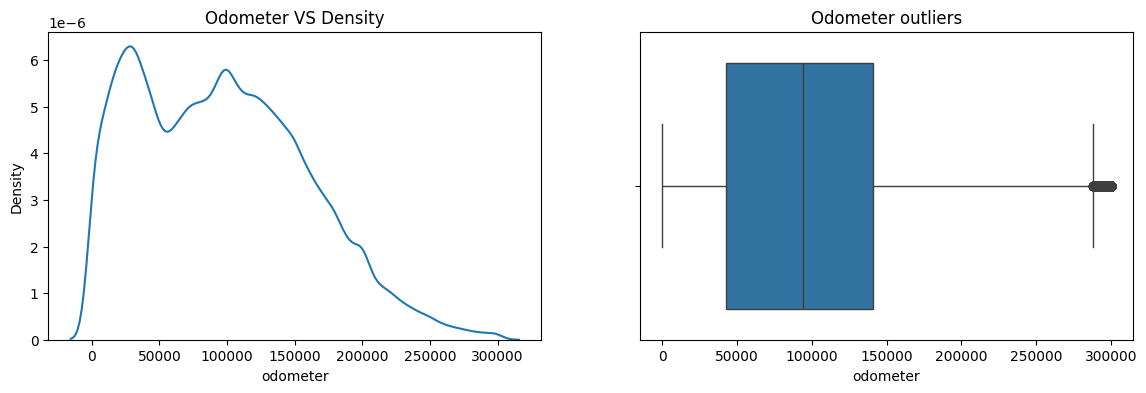

In [31]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(car_price['odometer'])
plt.title('Odometer VS Density')

plt.subplot(122)
sns.boxplot(x=car_price['odometer'])
plt.title('Odometer outliers')
plt.show()

#### Not Removing ALL Remaining Outliers bacause
- luxury cars genuinely exist
- low mileage cars genuinely exist
- high prices can be real

If aggressively remove all statistical outliers it can cause:
- model loses real-world variability
- dataset becomes unrealistic

## 4.2 Data Visualization

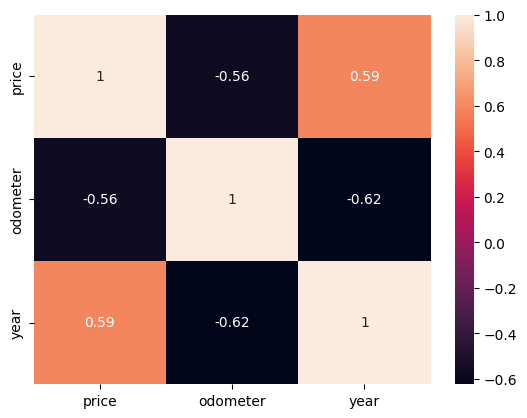

In [32]:
sns.heatmap(car_price[['price','odometer','year']].corr(),annot=True)
plt.show()

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


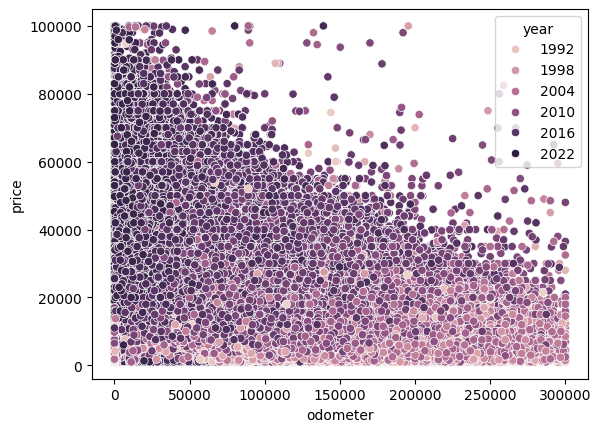

In [33]:
sns.scatterplot(x='odometer',y='price',hue='year',data=car_price)
plt.show()

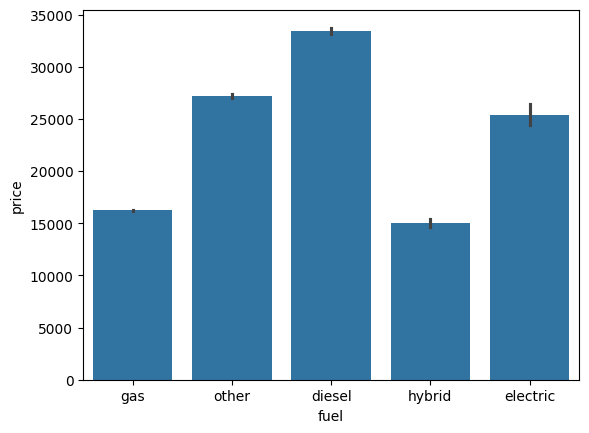

In [34]:
sns.barplot(x='fuel',y='price',data=car_price)
plt.show()

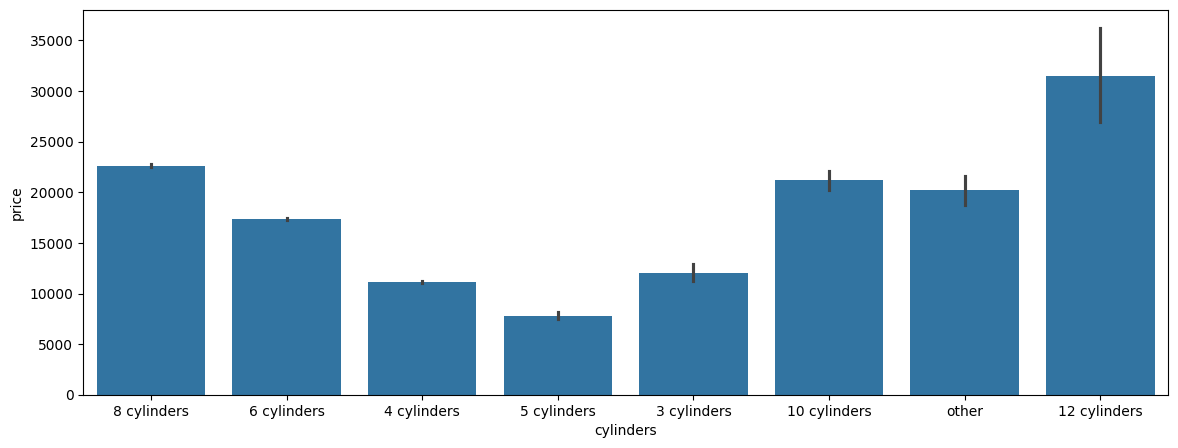

In [35]:
plt.figure(figsize=(14,5))
sns.barplot(x='cylinders',y='price',data=car_price)
plt.show()

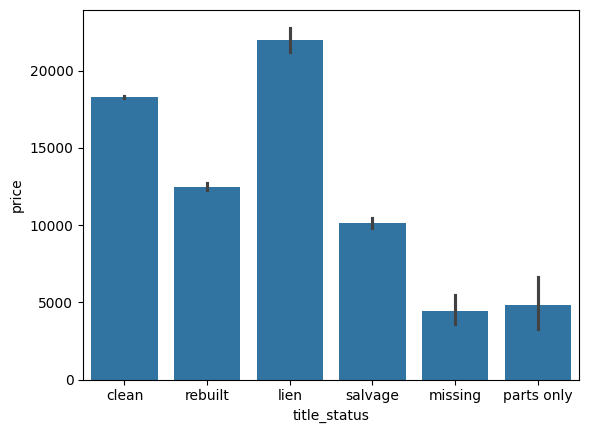

In [36]:
sns.barplot(x='title_status',y='price',data=car_price)
plt.show()

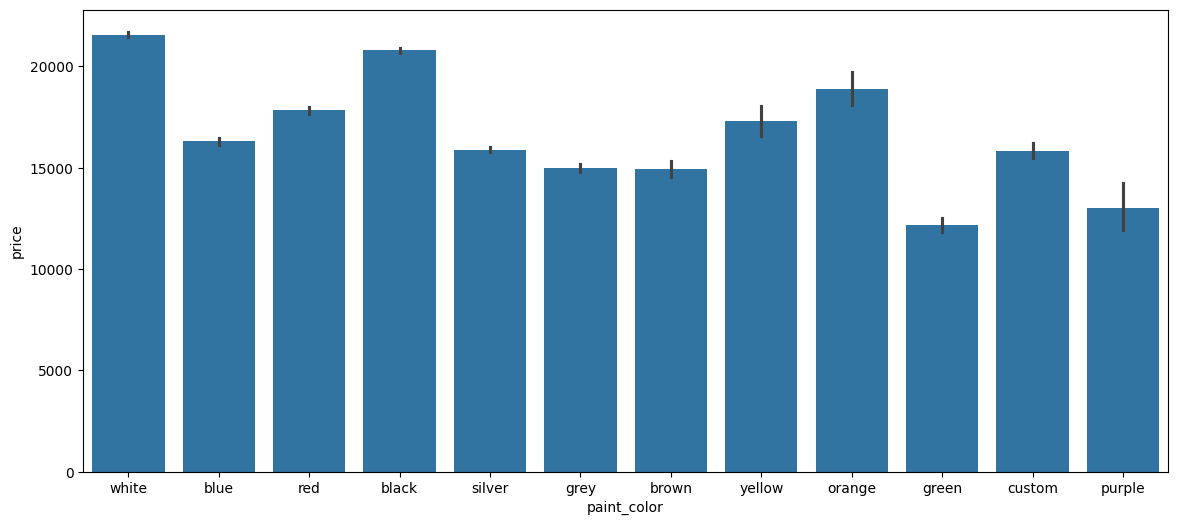

In [37]:
plt.figure(figsize=(14,6))
sns.barplot(x='paint_color',y='price',data=car_price)
plt.show()

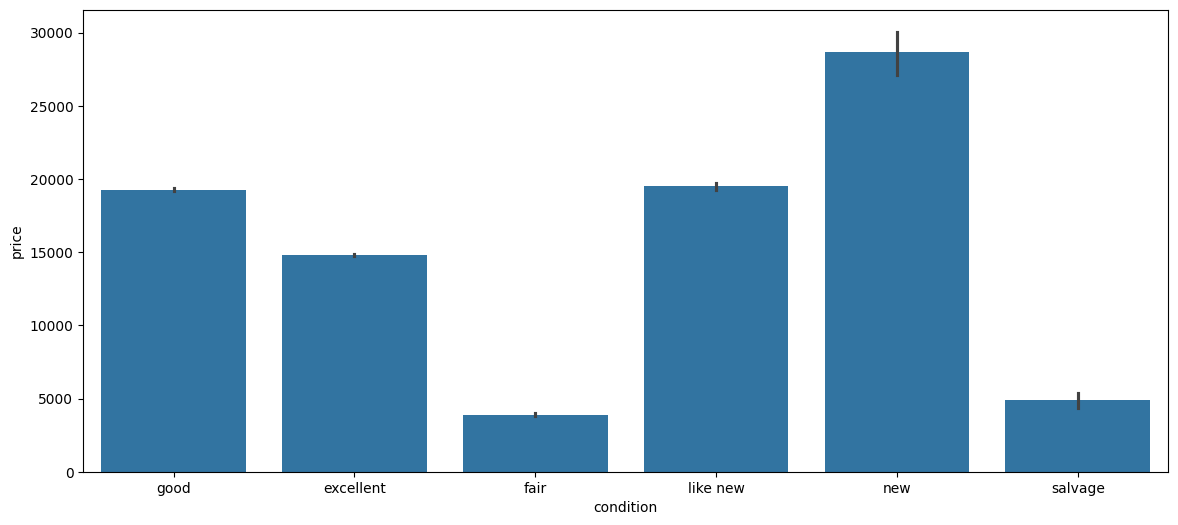

In [38]:
plt.figure(figsize=(14,6))
sns.barplot(x='condition',y='price',data=car_price)
plt.show()

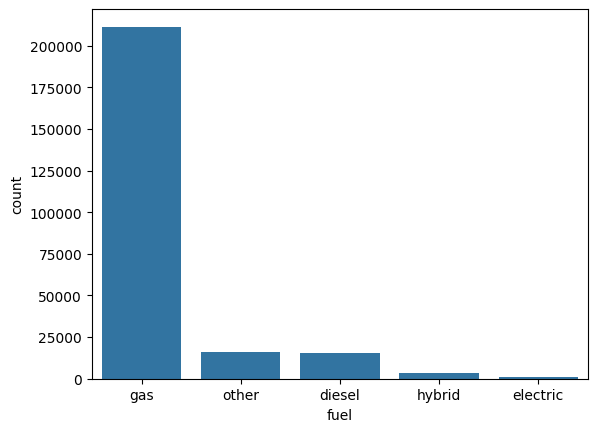

In [39]:
sns.countplot(x='fuel', data=car_price)
plt.show()

# 5. Feature Engineering

#### Finding Unique values of categorical columns

In [40]:
categorical_cols=[
    'fuel','transmission','title_status','manufacturer','model','condition','cylinders','drive','type','paint_color',
    'state']
for col in categorical_cols:
    print(f"{col}: {car_price[col].value_counts()}\n")

fuel: fuel
gas         211335
other        15850
diesel       15711
hybrid        3361
electric      1025
Name: count, dtype: int64

transmission: transmission
automatic    199500
other         34070
manual        13712
Name: count, dtype: int64

title_status: title_status
clean         237061
rebuilt         5641
salvage         3038
lien            1296
missing          178
parts only        68
Name: count, dtype: int64

manufacturer: manufacturer
ford               40138
chevrolet          30105
toyota             20923
honda              14177
nissan             11733
jeep               10913
gmc                 9287
ram                 9113
bmw                 8644
dodge               7464
subaru              6506
mercedes-benz       6497
hyundai             6240
volkswagen          5682
lexus               5127
kia                 5049
audi                4799
cadillac            4102
chrysler            3822
acura               3685
mazda               3353
buick               3

In [41]:
for col in categorical_cols:
    print(f"{col}: {car_price[col].unique()}\n")

fuel: ['gas' 'other' 'diesel' 'hybrid' 'electric']

transmission: ['other' 'automatic' 'manual']

title_status: ['clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']

manufacturer: ['gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac' 'honda' 'dodge' 'lexus' 'jaguar' 'buick' 'chrysler' 'volvo'
 'audi' 'infiniti' 'lincoln' 'alfa-romeo' 'subaru' nan 'acura' 'hyundai'
 'mercedes-benz' 'bmw' 'mitsubishi' 'volkswagen' 'porsche' 'kia' 'ferrari'
 'mini' 'pontiac' 'fiat' 'rover' 'tesla' 'saturn' 'mercury'
 'harley-davidson' 'aston-martin' 'land rover']

model: ['sierra 1500 crew cab slt' 'silverado 1500' 'silverado 1500 crew' ...
 'ATI' 'gand wagoneer' '96 Suburban']

condition: ['good' 'excellent' 'fair' 'like new' nan 'new' 'salvage']

cylinders: ['8 cylinders' '6 cylinders' nan '4 cylinders' '5 cylinders' '3 cylinders'
 '10 cylinders' 'other' '12 cylinders']

drive: [nan 'rwd' '4wd' 'fwd']

type: ['pickup' 'truck' 'other' nan 'coupe' 'SUV' 'hatchback' 'mini-van'

## 5.1 Reducing Cardinality

#### Taking only top 50 models of the cars and listing left models in "other"

In [42]:
top_models=car_price['model'].value_counts().nlargest(50).index
top_models

Index(['f-150', 'silverado 1500', '1500', 'camry', 'accord', 'civic',
       'silverado', 'altima', 'escape', 'wrangler', 'tacoma', 'grand cherokee',
       'explorer', '2500', 'corolla', 'cr-v', 'mustang', 'focus', 'equinox',
       'fusion', 'rav4', 'odyssey', 'outback', 'tahoe', 'malibu', 'sonata',
       'impala', 'prius', 'grand caravan', 'jetta', 'forester', 'sierra 1500',
       'elantra', 'cruze', 'silverado 2500hd', 'tundra', 'sentra', 'edge',
       'f-250', 'corvette', 'sierra', 'rogue', 'charger', '3500', 'f150',
       'highlander', 'wrangler unlimited', 'sienna', 'pilot', '4runner'],
      dtype='object', name='model')

In [43]:
car_price['model']=car_price['model'].apply(lambda x: x if x in top_models else 'other')
car_price['model']

27                 other
28        silverado 1500
29                 other
30                 other
31                 other
               ...      
426875             other
426876             other
426877             other
426878             other
426879             other
Name: model, Length: 247282, dtype: object

In [44]:
car_price[['no_of_cylinders','Cylinders']]=car_price['cylinders'].str.split(' ',n=1,expand=True)
car_price[['no_of_cylinders','Cylinders']]

,no_of_cylinders,Cylinders
27,8,cylinders
28,8,cylinders
29,8,cylinders
30,8,cylinders
31,6,cylinders
...,...,...
426875,6,cylinders
426876,NaN,NaN
426877,NaN,NaN
426878,6,cylinders


#### Dropping cylinders and cylinders columns as only number of cylinders are required 

In [45]:
car_price=car_price.drop(columns=['cylinders','Cylinders'])

In [46]:
car_price.dtypes

price                int64
year               float64
manufacturer        object
model               object
condition           object
fuel                object
odometer           float64
title_status        object
transmission        object
drive               object
type                object
paint_color         object
state               object
no_of_cylinders     object
dtype: object

##### Number of cylinders are still in categorical value so converting it.

In [47]:
car_price['no_of_cylinders'] = pd.to_numeric(
    car_price['no_of_cylinders'],
    errors='coerce'
)

## 5.2 Creating New Features

### Finding Car Age

In [48]:
curr_year=datetime.now().year
curr_year

2026

In [49]:
car_price['car_age']=curr_year - car_price['year']


In [50]:
car_price=car_price.drop(columns=['year'])

In [51]:
car_price.head(5)

,price,manufacturer,model,condition,fuel,odometer,title_status,transmission,drive,type,paint_color,state,no_of_cylinders,car_age
27,33590,gmc,other,good,gas,57923.0,clean,other,NaN,pickup,white,al,8.0,12.0
28,22590,chevrolet,silverado 1500,good,gas,71229.0,clean,other,NaN,pickup,blue,al,8.0,16.0
29,39590,chevrolet,other,good,gas,19160.0,clean,other,NaN,pickup,red,al,8.0,6.0
30,30990,toyota,other,good,gas,41124.0,clean,other,NaN,pickup,red,al,8.0,9.0
31,15000,ford,other,excellent,gas,128000.0,clean,automatic,rwd,truck,black,al,6.0,13.0


# 6. Train Test Split

In [52]:
X = car_price.drop(columns=['price'])
Y = car_price['price']

In [53]:
X_train,X_test,Y_train,Y_test=train_test_split( X , Y , test_size=0.2 , random_state=42)


# 7. Model Pipeline

## 7.1 Preprocessing Pipelines

### Why This Fix Works

In condition col if we use simple imputer and ordinal encoder seperately then :
- imputer and encoder run separately
- encoder still receives NaN values

After this fix:
- imputation happens FIRST
- encoder receives cleaned values

inside SAME mini-pipeline.

In [54]:
null_values_encoding=ColumnTransformer( [ 

    ("imputer_no_of_cylinders",SimpleImputer(strategy='median'),['no_of_cylinders']),

    ("ohe_manufacturer",Pipeline([
        ("impute",SimpleImputer(strategy='most_frequent') ),
        ("encode",OneHotEncoder(sparse_output=False,handle_unknown='ignore') )
    ]),['manufacturer'] ),
     
    ("ohe_model",OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['model']),
    
    ("ohe_fuel",OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['fuel']),
    
    ("ohe_title_status",OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['title_status']),
    
    ("ohe_transmission",OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['transmission']),

    
    ("ohe_drive",Pipeline([
        ("impute",SimpleImputer(strategy='constant',fill_value='other') ),
        ("encode",OneHotEncoder(sparse_output=False,handle_unknown='ignore') )
    ]),['drive']),

    

    ("ohe_type",Pipeline([
        ("impute",SimpleImputer(strategy='constant',fill_value='other') ),
        ("encode",OneHotEncoder(sparse_output=False,handle_unknown='ignore') )
    ]),['type']),


    

    ("ohe_paint_color",Pipeline([
        ("impute",SimpleImputer(strategy='constant',fill_value='other') ),
        ("encode",OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
    ]),['paint_color']),

    
    ("ohe_state",OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['state']),

    
    ("oe_condition",Pipeline( [
        ("imputer",SimpleImputer(strategy='constant',fill_value='other') ),
        ("encoder",OrdinalEncoder(categories=[['salvage','fair','other','good','excellent','like new','new']] ) )
    ]), ['condition'])
 ], remainder='passthrough')

## 7.2 Feature_selection

In [55]:
features=SelectKBest(score_func=f_regression,k='all')

## 7.3 Linear Regression is baseline Model 
therefore not applying feature scaling and log transformer

In [56]:
lr=LinearRegression()

## 7.3.1 Creating Pipeline

In [57]:
pipe_lr=Pipeline([
    ("null_values_encoding",null_values_encoding),
    ("features",features),
    ("lr",lr)
])

In [58]:
pipe_lr.fit(X_train,Y_train)

,steps,"[('null_values_encoding', ...), ('features', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('imputer_no_of_cylinders', ...), ('ohe_manufacturer', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
X_train_lr_transformed=pipe_lr.named_steps['null_values_encoding'].transform(X_train)
X_train_lr_transformed

array([[6.00000e+00, 0.00000e+00, 0.00000e+00, ..., 4.00000e+00,
        1.64000e+05, 1.90000e+01],
       [6.00000e+00, 0.00000e+00, 0.00000e+00, ..., 2.00000e+00,
        1.49111e+05, 1.30000e+01],
       [6.00000e+00, 0.00000e+00, 0.00000e+00, ..., 3.00000e+00,
        1.64000e+05, 2.70000e+01],
       ...,
       [6.00000e+00, 0.00000e+00, 0.00000e+00, ..., 2.00000e+00,
        1.40000e+05, 1.50000e+01],
       [6.00000e+00, 0.00000e+00, 1.00000e+00, ..., 2.00000e+00,
        2.89300e+04, 6.00000e+00],
       [6.00000e+00, 0.00000e+00, 0.00000e+00, ..., 5.00000e+00,
        1.80000e+05, 1.80000e+01]], shape=(197825, 190))

In [60]:
lr_features_names=pipe_lr.named_steps['null_values_encoding'].get_feature_names_out()
#lr_features_names

In [61]:
lr_features_names.shape

(190,)

## 7.3.2 Evaluation

In [62]:
X_train_lr_df=pd.DataFrame(X_train_lr_transformed,columns=lr_features_names,index=X_train.index)
X_train_lr_df.head(10)

,imputer_no_of_cylinders__no_of_cylinders,ohe_manufacturer__manufacturer_acura,ohe_manufacturer__manufacturer_alfa-romeo,ohe_manufacturer__manufacturer_aston-martin,ohe_manufacturer__manufacturer_audi,ohe_manufacturer__manufacturer_bmw,ohe_manufacturer__manufacturer_buick,ohe_manufacturer__manufacturer_cadillac,ohe_manufacturer__manufacturer_chevrolet,ohe_manufacturer__manufacturer_chrysler,...,ohe_state__state_ut,ohe_state__state_va,ohe_state__state_vt,ohe_state__state_wa,ohe_state__state_wi,ohe_state__state_wv,ohe_state__state_wy,oe_condition__condition,remainder__odometer,remainder__car_age
388956,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,164000.0,19.0
103998,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,149111.0,13.0
160097,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,164000.0,27.0
184890,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,20676.0,9.0
293428,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,197000.0,19.0
97897,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,119820.0,12.0
363259,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,120058.0,13.0
117370,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,91000.0,18.0
352349,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,57384.0,13.0
290592,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,20596.0,8.0


In [63]:
y_predict_lr= pipe_lr.predict(X_test)

mse = mean_squared_error(Y_test, y_predict_lr)
mae = mean_absolute_error(Y_test, y_predict_lr)
r2 = r2_score(Y_test, y_predict_lr)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 55338060.42198058
MAE: 5165.912898437824
R2 Score: 0.713748648948644


# 7.4 Random Forest

In [133]:
rf=RandomForestRegressor(n_estimators=50, random_state=42,n_jobs=-1)

## 7.4.1 Creating Pipeline

In [134]:
pipe_rf=Pipeline([
    ("null_values_encoding",null_values_encoding),
    ("Random_forest",rf)
])

In [135]:
pipe_rf.fit(X_train,Y_train)

,steps,"[('null_values_encoding', ...), ('Random_forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('imputer_no_of_cylinders', ...), ('ohe_manufacturer', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [136]:
X_train_rf_transformed=pipe_rf.named_steps['null_values_encoding'].transform(X_train)

In [137]:
X_train_rf_features=pipe_rf.named_steps['null_values_encoding'].get_feature_names_out()
X_train_rf_features.shape

(190,)

In [138]:
print(pipe_rf.named_steps.keys())

dict_keys(['null_values_encoding', 'Random_forest'])


## 7.4.2 Evaluation

In [139]:
X_train_rf_df=pd.DataFrame(X_train_rf_transformed,columns=X_train_rf_features,index=X_train.index)
X_train_rf_df.head()

,imputer_no_of_cylinders__no_of_cylinders,ohe_manufacturer__manufacturer_acura,ohe_manufacturer__manufacturer_alfa-romeo,ohe_manufacturer__manufacturer_aston-martin,ohe_manufacturer__manufacturer_audi,ohe_manufacturer__manufacturer_bmw,ohe_manufacturer__manufacturer_buick,ohe_manufacturer__manufacturer_cadillac,ohe_manufacturer__manufacturer_chevrolet,ohe_manufacturer__manufacturer_chrysler,...,ohe_state__state_ut,ohe_state__state_va,ohe_state__state_vt,ohe_state__state_wa,ohe_state__state_wi,ohe_state__state_wv,ohe_state__state_wy,oe_condition__condition,remainder__odometer,remainder__car_age
388956,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,164000.0,19.0
103998,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,149111.0,13.0
160097,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,164000.0,27.0
184890,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,20676.0,9.0
293428,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,197000.0,19.0


In [140]:
predict_rf= pipe_rf.predict(X_test)

mse = mean_squared_error(Y_test,predict_rf)
mae = mean_absolute_error(Y_test,predict_rf)
r2 = r2_score(Y_test,predict_rf)
print("mae:",mae)
print("mse:",mse)
print("r2 score:",r2)

mae: 2717.4106416843338
mse: 24448094.57409752
r2 score: 0.8735355007186523


 decrease of 56% mse as compared to linear regression mse
 
 decrease of 47.3% mae as compared to linear regression mae

# 7.5 Feature Importance

In [79]:
importance= pipe_rf.named_steps['Random_forest'].feature_importances_

In [111]:
feature_importance=pd.DataFrame( {
    'features': X_train_rf_features , 
    'importance' : importance
}).sort_values(ascending=False,by='importance')
top10 = feature_importance.head(10)

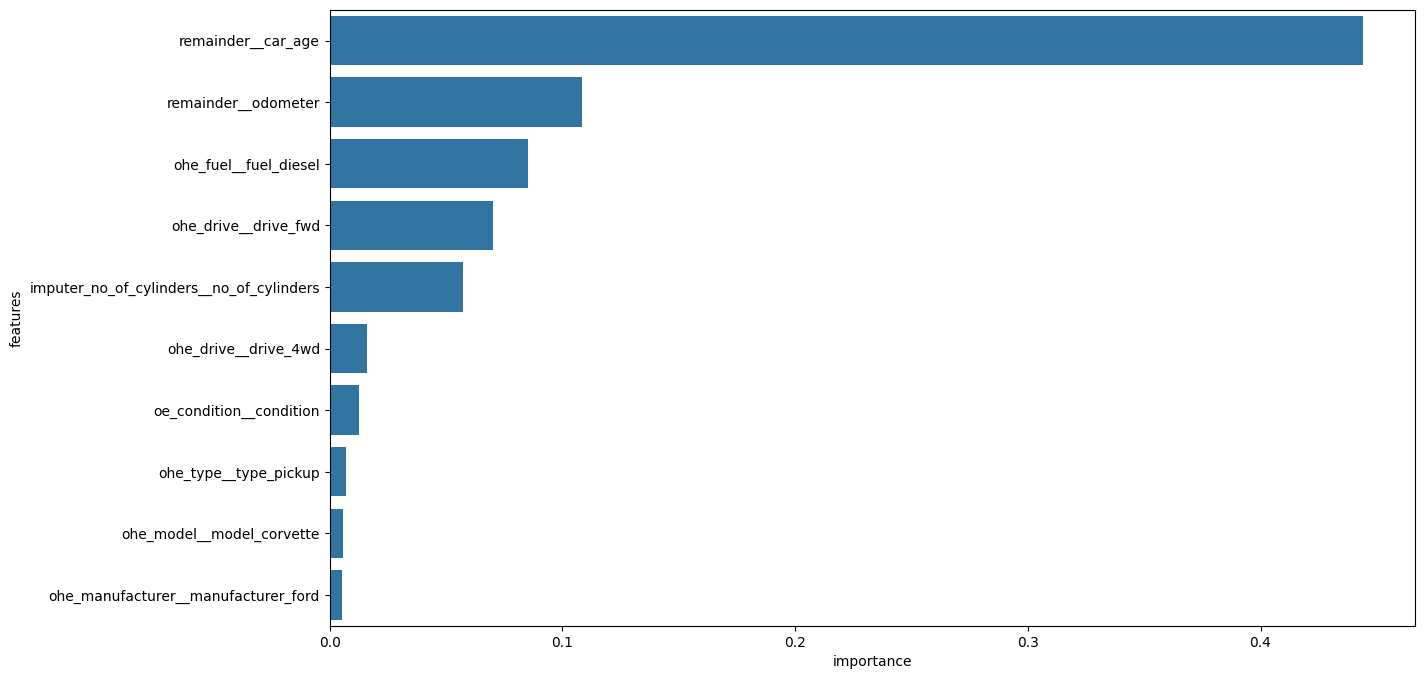

In [112]:
plt.figure(figsize=(14,8))
sns.barplot(x='importance',y='features',data=top10)
plt.show()

# 7.6 XGBoost

## 7.6.1 Default

In [129]:


xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

pipe_xgb = Pipeline([
    ("null_values_encoding", null_values_encoding),
    ("XGBoost", xgb)
])

pipe_xgb.fit(X_train, Y_train)

# Evaluation
predict_xgb = pipe_xgb.predict(X_test)

mse = mean_squared_error(Y_test, predict_xgb)
mae = mean_absolute_error(Y_test, predict_xgb)
r2 = r2_score(Y_test, predict_xgb)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 3480.0068359375
MSE: 30580916.0
R2 Score: 0.8418117761611938


## 7.6.2 Tune XGBoost

In [130]:
xgb_tune = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

pipe_xgb_tune = Pipeline([
    ("null_values_encoding", null_values_encoding),
    ("XGBoost", xgb_tune)
])

pipe_xgb_tune.fit(X_train, Y_train)

# Evaluation
predict_xgb_tune = pipe_xgb_tune.predict(X_test)

mse = mean_squared_error(Y_test, predict_xgb_tune)
mae = mean_absolute_error(Y_test, predict_xgb_tune)
r2 = r2_score(Y_test, predict_xgb_tune)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 3629.88134765625
MSE: 32890544.0
R2 Score: 0.8298646211624146


## 7.6.3 Log Transform + XGBoost

In [131]:

# Log transform target
Y_train_log = np.log1p(Y_train)

xgb_log = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

pipe_xgb_log = Pipeline([
    ("null_values_encoding", null_values_encoding),
    ("XGBoost", xgb_log)
])

pipe_xgb_log.fit(X_train, Y_train_log)

# Reverse log transform on predictions
predict_xgb_log = np.expm1(pipe_xgb_log.predict(X_test))

mse = mean_squared_error(Y_test, predict_xgb_log)
mae = mean_absolute_error(Y_test, predict_xgb_log)
r2 = r2_score(Y_test, predict_xgb_log)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 3595.797607421875
MSE: 35993920.0
R2 Score: 0.8138115406036377


# 8.Saving Model in Pickle File

In [144]:
joblib.dump(pipe_rf, "car_price_prediction_rf_xgb.joblib", compress=3)

['car_price_prediction_rf_xgb.joblib']

# 9. Conclusion



## Model Comparison

| Model | R² Score | MAE | MSE |
|-------|----------|-----|-----|
| Linear Regression (Baseline) | 0.7190 | 5,279.54 | 56,751,592 |
| XGBoost + Log Transform | 0.8138 | 3,595.79 | 35,993,920 |
| XGBoost (tuned) | 0.8298 | 3,629.88 | 32,890,544 |
| XGBoost (default) | 0.8418 | 3,480.00 | 30,580,916 |
| **Random Forest (150 trees)** | **0.8753** | **2,691.16** | **24,104,963** |

> Random Forest outperformed all models including 3 XGBoost variants, achieving **+15.6 R² points** over baseline and reducing MAE by **$2,588**. XGBoost underperformed due to high-dimensional sparse OHE features — target encoding is expected to close this gap in future iterations.

## Key Findings from EDA
- Higher odometer readings correlate negatively with price (expected depreciation)
- Newer cars (lower `car_age`) command significantly higher prices
- Diesel and electric fuel types show higher average prices than gas
- `salvage` title status significantly drops car value
- 8-cylinder cars price considerably higher than 4-cylinder equivalents

## Feature Importance Insights (Random Forest)
- `car_age` is the single most dominant feature (~0.40 importance), validating the feature engineering decision to derive it from `year`
- `odometer` ranks second (~0.12), confirming depreciation as a core price driver
- High-cardinality OHE columns (`state`, `model`, `paint_color`) contribute near-zero individual importance — candidate for removal or target encoding in future iterations

## Limitations
- No cross-validation performed; metrics are from a single 80/20 split
- High-cardinality OHE columns add ~180 sparse features, most with negligible importance
- Random Forest is computationally expensive at 426K rows
- XGBoost performance limited by OHE sparse feature space; target encoding recommended

## Next Steps
- [x] Train XGBoost and compare against Random Forest
- [ ] Train LightGBM
- [ ] Apply target encoding for high-cardinality columns and re-evaluate XGBoost
- [ ] HPT on best performing model after target encoding
- [ ] Use 5-fold cross-validation for reliable metric reporting